**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc1_)    
- [Load Data set](#toc2_)    
- [Understanding Data](#toc3_)    
- [Global constants](#toc4_)    
- [Model 1 - Classification](#toc5_)    
  - [Selecting 5 categories and labels](#toc5_1_)    
  - [Split data to train(fit) and test(predict)](#toc5_2_)    
    - [Understanding split data](#toc5_2_1_)    
  - [Using LDA clasification](#toc5_3_)    
    - [LDA without hyper parameter tuning](#toc5_3_1_)    
    - [LDA with hyper parameter tuning](#toc5_3_2_)    
    - [LDA with normalization and hyper parameter tuning](#toc5_3_3_)    
  - [Logistic regression](#toc5_4_)    
    - [Without hyperparamter tuning](#toc5_4_1_)    
    - [With hyperparameter Tuning](#toc5_4_2_)    
    - [With Normalization](#toc5_4_3_)    
- [Model 2 - Preprocessing with classification](#toc6_)    
  - [Prerocessing with LDA feature/dimensionality reduction](#toc6_1_)    
    - [LDA without noramlisation and no hyper parameters](#toc6_1_1_)    
    - [LDA with noramlisation and no hyper parameters](#toc6_1_2_)    
    - [LDA with noramlisation and hyper parameters](#toc6_1_3_)    
      - [Optimization for finding best hyper parameters](#toc6_1_3_1_)    
        - [Grid search optimization to find best c value](#toc6_1_3_1_1_)    
        - [SA search](#toc6_1_3_1_2_)    
  - [Prerocessing with HOG feature extraction reduction](#toc6_2_)    
- [Model 3 - CNN](#toc7_)    
  - [Helper methods](#toc7_1_)    
    - [Data Agumentation](#toc7_1_1_)    
  - [Image agumentation and split](#toc7_2_)    
  - [Save the data and model](#toc7_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Imports](#toc0_)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
import skimage.feature
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore

# <a id='toc2_'></a>[Load Data set](#toc0_)

In [ ]:
data = np.load('./DS_Xdata.npy')
labels = np.load('./Ydata.npy')

# <a id='toc3_'></a>[Understanding Data](#toc0_)

In [ ]:
print(f"Shape: {data.shape}")
print(f"Sample count: {len(labels)}")
print(f"Unique label: {np.unique(labels)}")

Shape: (2100, 61, 61, 3)
Sample count: 2100
Unique label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


# <a id='toc4_'></a>[Global constants](#toc0_)

In [ ]:
#Value to replicate the random value generation in the file
seeding_constant = 20

#Categories to be selected for classification
category_count = 5

# <a id='toc5_'></a>[Model 1 - Classification](#toc0_)

## <a id='toc5_1_'></a>[Selecting 5 categories and labels](#toc0_)

In [ ]:
np.random.seed(seeding_constant)

unique_label_set = set(np.unique(labels))

selected_categories = [np.random.randint(min(unique_label_set), 
                                         max(unique_label_set)) 
                        for _ in range(category_count)
                        ]

selected_data = [] 
selected_labels = [] 

for index, value in enumerate(labels):
    if value[0] in selected_categories:
        selected_data.append(data[index])
        selected_labels.append(value[0])

## <a id='toc5_2_'></a>[Split data to train(fit) and test(predict)](#toc0_)

In [ ]:
split_list = train_test_split(selected_data,
                              selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_model_1_and_2_data = split_list[0]
test_model_1_and_2_data = split_list[1]
train_model_1_and_2_labels = split_list[2]
test_model_1_and_2_labels = split_list[3]

### <a id='toc5_2_1_'></a>[Understanding split data](#toc0_)

In [ ]:
unique_train_labels = set(np.unique(train_model_1_and_2_labels))

print("Train Data diversification")
for i in unique_train_labels:
    print(f"Label {i} : {train_model_1_and_2_labels.count(i)}")

print("--"*25)

unique_test_labels = np.unique(test_model_1_and_2_labels)
print("Test Data diversification")
for i in unique_test_labels:
    print(f"Label {i} : {test_model_1_and_2_labels.count(i)}")

## <a id='toc5_3_'></a>[Using LDA clasification](#toc0_)

In [ ]:
# Reshape each image to a 1D array
num_features = np.prod(train_model_1_and_2_data[0].shape) 

train_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in train_model_1_and_2_data])
test_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in test_model_1_and_2_data])


### <a id='toc5_3_1_'></a>[LDA without hyper parameter tuning](#toc0_)

In [ ]:
lda= LDA(n_components=3)
lda.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

result_model1 = lda.predict(test_model_1_and_2_data_reshaped)

In [ ]:
print(f"LDA Accuracy: {lda.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels)}")

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=result_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_3_2_'></a>[LDA with hyper parameter tuning](#toc0_)

In [ ]:
lda2= LDA(n_components=4, solver="eigen", shrinkage='auto' )
lda2.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

result2_model1 = lda2.predict(test_model_1_and_2_data_reshaped)


In [ ]:
print(lda2.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=result2_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_3_3_'></a>[LDA with normalization and hyper parameter tuning](#toc0_)

In [ ]:
lda3= LDA(n_components=4, solver="eigen", shrinkage='auto' )

normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

lda3.fit(normalized_train_data, train_model_1_and_2_labels)

result3_model1 = lda3.predict(normalized_test_data)


In [ ]:
print(lda3.score(normalized_test_data, test_model_1_and_2_labels))

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(normalized_test_data[:,0], 
               normalized_test_data[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(normalized_test_data[:,0], 
               normalized_test_data[:,1],
               c=result3_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

## <a id='toc5_4_'></a>[Logistic regression](#toc0_)

### <a id='toc5_4_1_'></a>[Without hyperparamter tuning](#toc0_)

In [ ]:
# Train a classifier on the reduced training data
classifier1 = LogisticRegression(max_iter=1000)
classifier1.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels1 = classifier1.predict(test_model_1_and_2_data_reshaped)

print(classifier1.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=predicted_labels1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_4_2_'></a>[With hyperparameter Tuning](#toc0_)

In [ ]:
# Train a classifier on the reduced training data
classifier2 = LogisticRegression(max_iter=2500, solver='sag', C=15)
classifier2.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels2 = classifier2.predict(test_model_1_and_2_data_reshaped)

print(classifier2.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

### <a id='toc5_4_3_'></a>[With Normalization](#toc0_)

In [ ]:
normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

# Train a classifier on the reduced training data
classifier3 = LogisticRegression(max_iter=1000)
classifier3.fit(normalized_train_data, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels3 = classifier3.predict(normalized_test_data)

print(classifier3.score(normalized_test_data, test_model_1_and_2_labels))

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=predicted_labels3,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

# <a id='toc6_'></a>[Model 2 - Preprocessing with classification](#toc0_)

In [ ]:
# Reshape each image to a 1D array
num_features = np.prod(train_model_1_and_2_data[0].shape) 

train_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in train_model_1_and_2_data])
test_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in test_model_1_and_2_data])

## <a id='toc6_1_'></a>[Prerocessing with LDA feature/dimensionality reduction](#toc0_)

### <a id='toc6_1_1_'></a>[LDA without noramlisation and no hyper parameters](#toc0_)

In [ ]:
lda4= LDA(n_components=4)
train_transformed1_moldel2 = lda4.fit_transform(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

test_transformed1_moldel2 = lda4.transform(test_model_1_and_2_data_reshaped)

In [ ]:
# Train a classifier on the reduced training data
classifier4 = LogisticRegression(max_iter=1000)
classifier4.fit(train_transformed1_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels4 = classifier4.predict(test_transformed1_moldel2)

print(classifier4.score(test_transformed1_moldel2, test_model_1_and_2_labels))

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed1_moldel2[:,0], 
               test_transformed1_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed1_moldel2[:,0], 
               test_transformed1_moldel2[:,1],
               c=predicted_labels4,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc6_1_2_'></a>[LDA with noramlisation and no hyper parameters](#toc0_)

In [ ]:
normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

In [ ]:
lda5= LDA(n_components=4, )
train_transformed2_moldel2 = lda5.fit_transform(normalized_train_data, train_model_1_and_2_labels)

test_transformed2_moldel2 = lda5.transform(normalized_test_data)


In [ ]:
# Train a classifier on the reduced training data
classifier5 = LogisticRegression(max_iter=1000)
classifier5.fit(train_transformed2_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels5 = classifier5.predict(test_transformed2_moldel2)

print(classifier5.score(test_transformed2_moldel2, test_model_1_and_2_labels))

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed2_moldel2[:,0], 
               test_transformed2_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed2_moldel2[:,0], 
               test_transformed2_moldel2[:,1],
               c=predicted_labels5,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc6_1_3_'></a>[LDA with noramlisation and hyper parameters](#toc0_)

In [ ]:
lda6= LDA(n_components=3, solver="eigen", shrinkage='auto')
train_transformed3_moldel2 = lda6.fit_transform(normalized_train_data, train_model_1_and_2_labels)

test_transformed3_moldel2 = lda6.transform(normalized_test_data)


In [ ]:
classifier6 = LogisticRegression(max_iter=1000, C=5.294)
classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
print(f"{classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)}")

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed3_moldel2[:,0], 
               test_transformed3_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed3_moldel2[:,0], 
               test_transformed3_moldel2[:,1],
               c=predicted_labels6,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

#### <a id='toc6_1_3_1_'></a>[Optimization for finding best hyper parameters](#toc0_)

##### <a id='toc6_1_3_1_1_'></a>[Grid search optimization to find best c value](#toc0_)

In [ ]:
# Train a classifier on the reduced training data
for i in np.linspace(5, 7, 10000):
    classifier6 = LogisticRegression(max_iter=1000, C=round(float(i), 3))
    classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

    # Predict labels for the reduced test data
    predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
    score = classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)
    if(score>0.58):
        print(f"{round(float(i), 3)}:{score}")

##### <a id='toc6_1_3_1_2_'></a>[SA search](#toc0_)

In [ ]:
from scipy.optimize import dual_annealing
from sklearn.model_selection import cross_val_score
from sklearn.multiclass import OneVsRestClassifier

# Objective function for Simulated Annealing
def objective(params):
    C, penalty_idx, solver_idx = params

     
    try:
        float(C)
        int(penalty_idx)
        int(solver_idx)
        if C <= 0 or penalty_idx < 0 or solver_idx < 0:
            return np.inf
    except:
        return np.inf
    
    
    C = round(C, 3)


    penalties = ['l2', 'elasticnet']
    solvers = ['newton-cg', 'sag', 'saga']
    
    penalty = penalties[int(penalty_idx)]
    solver = solvers[int(solver_idx)]

    # Ensure compatibility between solver and penalty
    if penalty == 'elasticnet' and solver!='saga':
        return np.inf
    
    try:
        # Logistic Regression model
        model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=5000)
        
        # Cross-validated accuracy
        score = cross_val_score(model, test_transformed3_moldel2, test_model_1_and_2_labels, cv=5, scoring='accuracy').mean()
        
        if np.isnan(score):
            return np.inf

        return -score  # Negative because `dual_annealing` minimizes
    except Exception as e:
        return np.inf  # Return a very low score if an error occurs

# Define bounds for each parameter
bounds = [
    (3, 7),          # C: Regularization strength
    (0, 1.99),            # Penalty index: 0 = 'l2', 1 = 'elasticnet'
    (0, 2.99)           # Multi-class index: 0 = 'ovr', 1 = 'multinomial'
]

# Run dual annealing
result = dual_annealing(objective, bounds, maxiter=1000)
best_params = result.x
print("Best Parameters (Raw Indices):", best_params)

# Convert indices to parameter values
best_C = best_params[0]
best_penalty = ['l2', 'elasticnet'][int(best_params[1])]
best_solver = ['lbfgs', 'newton-cg', 'sag', 'saga'][int(best_params[2])]

print("Best C:", best_C)
print("Best Penalty:", best_penalty)
print("Best Solver:", best_solver)
print("Best Cross-Validated Accuracy:", -result.fun)


In [ ]:
classifier6 = LogisticRegression(max_iter=1000, C=5.294)
classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
score = classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)
print(score)

## <a id='toc6_2_'></a>[Prerocessing with HOG feature extraction reduction](#toc0_)

In [ ]:
hog_features = []

for index, image in enumerate(np.array(selected_data)):
    hog_feature, hog_image = skimage.feature.hog(image, 
                                                 pixels_per_cell=[10, 10], 
                                                 cells_per_block=[5, 5], 
                                                 visualize=True,
                                                 channel_axis=2
                                                )

    hog_features.append(hog_feature)

In [ ]:
np.array(hog_features).shape

In [ ]:
split_list_post_hog = train_test_split(hog_features,
                                       selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_data_post_hog = np.array(split_list_post_hog[0])
test_data_post_hog = np.array(split_list_post_hog[1])

train_labels_post_hog = np.array(split_list_post_hog[2])
test_labels_post_hog = np.array(split_list_post_hog[3])


In [ ]:
classifier7 = LogisticRegression(max_iter=1000)
classifier7.fit(train_data_post_hog, train_labels_post_hog)

# Predict labels for the reduced test data
predicted_labels7 = classifier7.predict(test_data_post_hog)
print(f"{classifier7.score(test_data_post_hog, test_labels_post_hog)}")

In [ ]:
plt.ion()
# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_data_post_hog[:,2], 
            test_data_post_hog[:,3],
            c=test_labels_post_hog,
            cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_data_post_hog[:,2], 
            test_data_post_hog[:,3],
            c=predicted_labels7,
            cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

In [ ]:
# Start interactive mode
plt.ion()

    # Create the figure and subplots for 3D plots (one 3D subplot for each)
fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(121, projection='3d')  # Ground truth plot
ax2 = fig.add_subplot(122, projection='3d')  # Predicted categories plot

# Plot ground truth (3D)
scatter1 = ax1.scatter(test_data_post_hog[:, 2], 
                        test_data_post_hog[:, 3],
                        test_data_post_hog[:, 4],  # Adding third dimension
                        c=test_labels_post_hog, 
                        cmap='Accent')
ax1.set_xlabel("Dimension 0")
ax1.set_ylabel("Dimension 1")
ax1.set_zlabel("Dimension 2")
ax1.set_title(f"Ground Truth : {i}")

# Plot predicted truth (3D)
scatter2 = ax2.scatter(test_data_post_hog[:, 2], 
                        test_data_post_hog[:, 3],
                        test_data_post_hog[:, 4],  # Adding third dimension
                        c=predicted_labels7, 
                        cmap='Accent')
ax2.set_xlabel("Dimension 0")
ax2.set_ylabel("Dimension 1")
ax2.set_zlabel("Dimension 2")
ax2.set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

# Turn off interactive mode and show the plot at the end
plt.show()

# <a id='toc7_'></a>[Model 3 - CNN](#toc0_)

## <a id='toc7_1_'></a>[Helper methods](#toc0_)

### <a id='toc7_1_1_'></a>[Data Agumentation](#toc0_)

In [ ]:
def image_generator(image, num_augmented_images = 5):
    # Set up the ImageDataGenerator with your desired augmentations
    datagen = ImageDataGenerator(
        rotation_range=0,             # No random rotations
        shear_range=0.2,              # Shear transformations
        zoom_range=0.2,               # Zoom range (20%)
        horizontal_flip=True,         # Horizontal flip
        vertical_flip=True,           # Vertical flip
        fill_mode='nearest'  # Use custom rotation function
    )

    img_array = np.expand_dims(image, axis=0)  # Add a batch dimension

    # Array to hold augmented images
    augmented_images = []

    # Number of augmented images to generate
    num_augmented_images = 5

    # Generate augmented images and store them in the array
    for batch in datagen.flow(img_array, batch_size=1):
        augmented_images.append(batch[0])  # Add the augmented image to the list
        if len(augmented_images) >= num_augmented_images:
            break  # Stop after generating the desired number of augmented images


    # Convert the list of augmented images to a NumPy array for easier processing
    augmented_images_array = np.array(augmented_images)

    aguemnted_image_array_270=np.rot90(augmented_images_array, axes=(1,2))
    aguemnted_image_array_180=np.rot90(augmented_images_array, k=2)
    aguemnted_image_array_90=np.rot90(augmented_images_array, k=3, axes=(1,2))

    # merge all the images to a single array
    all_images_array = np.concatenate((augmented_images_array, aguemnted_image_array_90, aguemnted_image_array_180, aguemnted_image_array_270))

    return all_images_array


## <a id='toc7_2_'></a>[Image agumentation and split](#toc0_)

In [ ]:
agumented_images = np.array(np.copy(data))
agumented_label_list = np.copy(labels).flatten()

for i in range(len(data)):
    # Extract the image and its corresponding label
    images_result= image_generator(data[i, :, :, :])
    # Append the augmented images to the list
    agumented_images = np.concatenate((agumented_images, images_result))

    repeated_labels = np.repeat(labels[i], images_result.shape[0])  # Repeat the label for the batch of images
    
    # Append the repeated labels
    agumented_label_list = np.concatenate((agumented_label_list, repeated_labels))

0
2100
100
4100
200
6100
300
8100
400
10100
500
12100
600
14100
700
16100
800
18100
900
20100
1000
22100
1100
24100
1200
26100
1300
28100
1400
30100
1500
32100
1600
34100
1700
36100
1800
38100
1900
40100
2000
42100


In [108]:
len(agumented_label_list)

44100

In [120]:
split_list_cnn = train_test_split(agumented_images,
                              agumented_label_list,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_model_cnn_data = split_list_cnn[0]
test_model_cnn_data = split_list_cnn[1]
train_model_cnn_labels = split_list_cnn[2]
test_model_cnn_labels = split_list_cnn[3]

In [187]:
normalized_cnn_train_data = train_model_cnn_data/255
normalized_cnn_test_data = test_model_cnn_data/255

In [ ]:
#Filter variables for cnn
filter_count = 32
multiplier=0


#Define the model with layers and hyperparams as per requiremnets
model_cnn_terrain = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(labels)), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn_terrain.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn_terrain = model_cnn_terrain.fit(normalized_cnn_train_data,
                                train_model_cnn_labels,
                                epochs = 6,
                                validation_split = 0.1,
                                verbose = 1
                                )

Epoch 1/6
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 71s 58ms/step - loss: 2.2349 - sparse_categorical_accuracy: 0.3918 - val_loss: 0.8193 - val_sparse_categorical_accuracy: 0.7415
Epoch 2/6
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 63s 56ms/step - loss: 0.8753 - sparse_categorical_accuracy: 0.7152 - val_loss: 0.4650 - val_sparse_categorical_accuracy: 0.8425
Epoch 3/6
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 130s 117ms/step - loss: 0.5473 - sparse_categorical_accuracy: 0.8189 - val_loss: 0.3317 - val_sparse_categorical_accuracy: 0.8917
Epoch 4/6
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 115s 103ms/step - loss: 0.3792 - sparse_categorical_accuracy: 0.8727 - val_loss: 0.2401 - val_sparse_categorical_accuracy: 0.9224
Epoch 5/6
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - loss: 0.2845 - sparse_categorical_accuracy: 0.9017 - val_loss: 0.1925 - val_sparse_categorical_accuracy: 0.9385
Epoch 6/6
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 61s 54ms/step - loss: 0.2150 - sparse_categorical_accuracy: 0.9275 - val_loss: 0.1650 - val_sparse_categorical

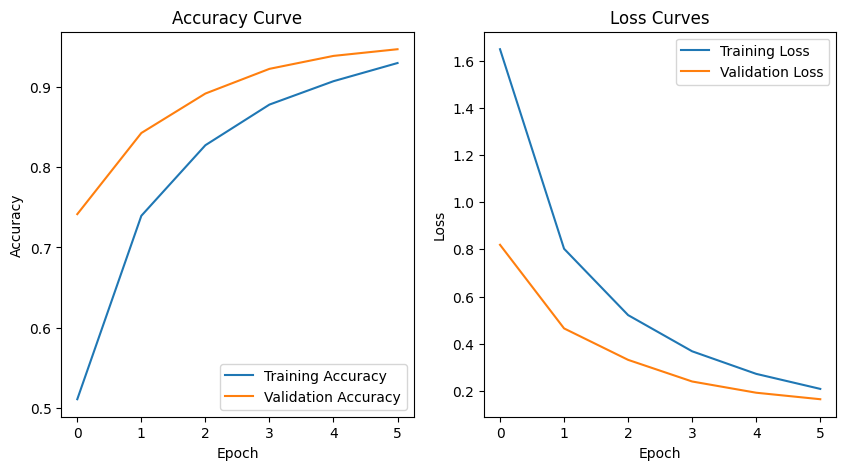

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn_terrain.history['sparse_categorical_accuracy'])
plt.plot(history_cnn_terrain.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curve')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn_terrain.history['loss'])
plt.plot(history_cnn_terrain.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

In [185]:
model_cnn_terrain.summary()

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_172 (Conv2D)             │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_150               │ (None, 29, 29, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_173 (Conv2D)             │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_174 (Conv2D)             │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_151               │ (None, 12, 12, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_175 (Conv2D)             │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_152               │ (None, 5, 5, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_54 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [ ]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn_terrain = model_cnn_terrain.evaluate(normalized_cnn_test_data, test_model_cnn_labels)

print(f'Test set loss: {results_cnn_terrain[0]:0.2f}, test set accuracy: {results_cnn_terrain[1]*100:0.2f}%')

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1581 - sparse_categorical_accuracy: 0.9478
Test set loss: 0.18, test set accuracy: 94.26%


## <a id='toc7_3_'></a>[Save the data and model](#toc0_)

In [130]:
# Save the data and labels as .npy files
np.save('agumented_data.npy', agumented_images)  # Save training data
np.save('agumented_label_list.npy', agumented_label_list)  # Save training labels


In [190]:
model_cnn_terrain.save('model_cnn_terrain_validation946_test942.keras') 